<a href="https://colab.research.google.com/github/AlifHammam/data-science-2026/blob/main/Pertemuan5_AlifHammamMultazam_240401010043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 5 - Visualisasi Data

**Nama Lengkap:** Alif Hammam Multazam  
**NIM:** 240401010043  
**Kelas:** IF403

## 1. Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = sns.load_dataset('tips')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(2))

Shape: (244, 7)
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


## 2. Grafik Dasar dengan Matplotlib

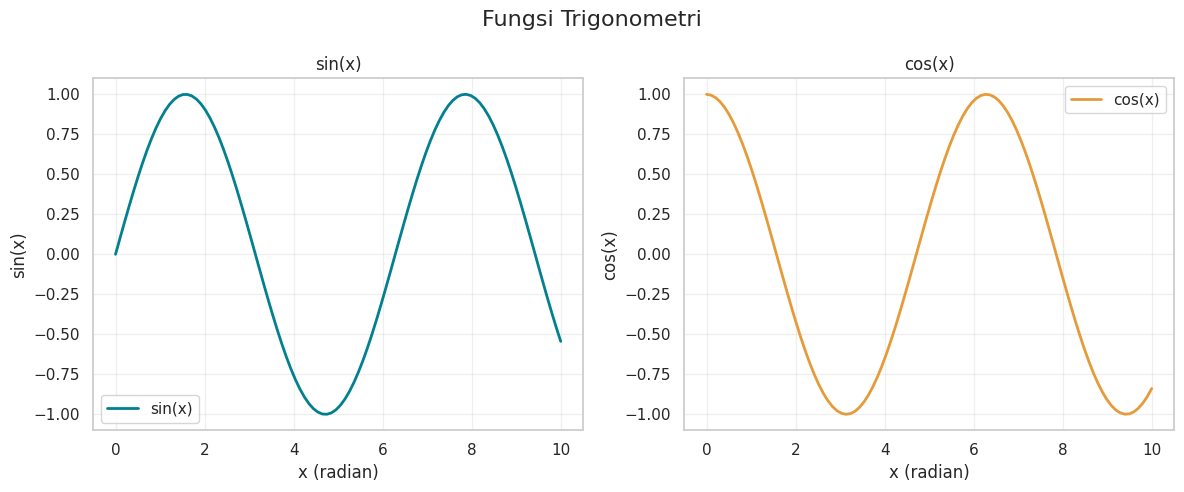

In [2]:
# Arsitektur Figure & Axes — contoh plot fungsi sinus dan cosinus
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.linspace(0, 10, 100)

axes[0].plot(x, np.sin(x), color='#028090', linewidth=2, label='sin(x)')
axes[0].set_title('sin(x)')
axes[0].set_xlabel('x (radian)')
axes[0].set_ylabel('sin(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.cos(x), color='#E69B3A', linewidth=2, label='cos(x)')
axes[1].set_title('cos(x)')
axes[1].set_xlabel('x (radian)')
axes[1].set_ylabel('cos(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fungsi Trigonometri', fontsize=16)
plt.tight_layout()
plt.show()

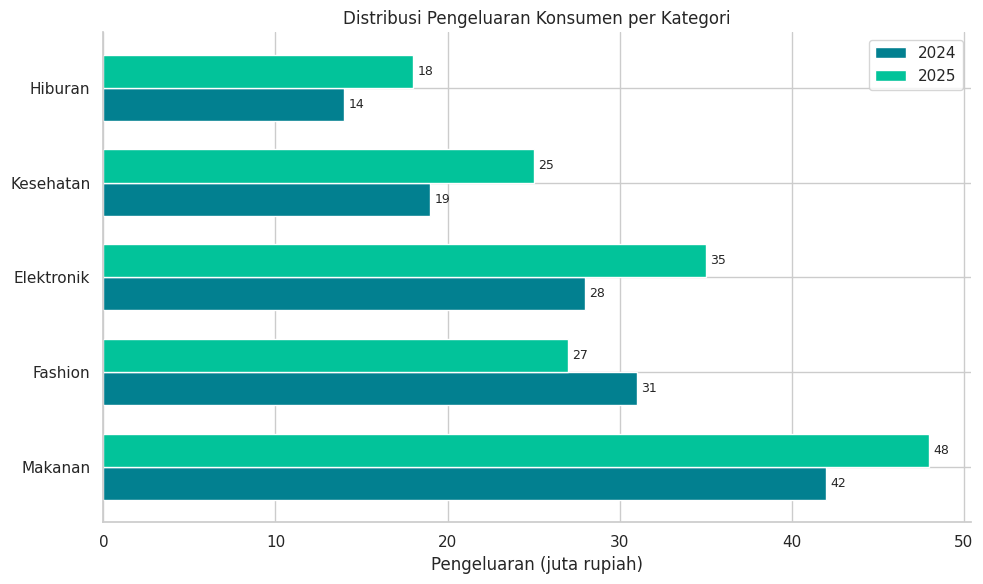

In [3]:
# Bar Chart — Perbandingan antar kategori
kategori  = ['Makanan', 'Fashion', 'Elektronik', 'Kesehatan', 'Hiburan']
val_2024  = [42, 31, 28, 19, 14]
val_2025  = [48, 27, 35, 25, 18]
x = np.arange(len(kategori))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.barh(x - width/2, val_2024, width, label='2024', color='#028090', edgecolor='white')
bars2 = ax.barh(x + width/2, val_2025, width, label='2025', color='#02C39A', edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(kategori)
ax.set_xlabel('Pengeluaran (juta rupiah)')
ax.set_title('Distribusi Pengeluaran Konsumen per Kategori')
ax.legend()
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

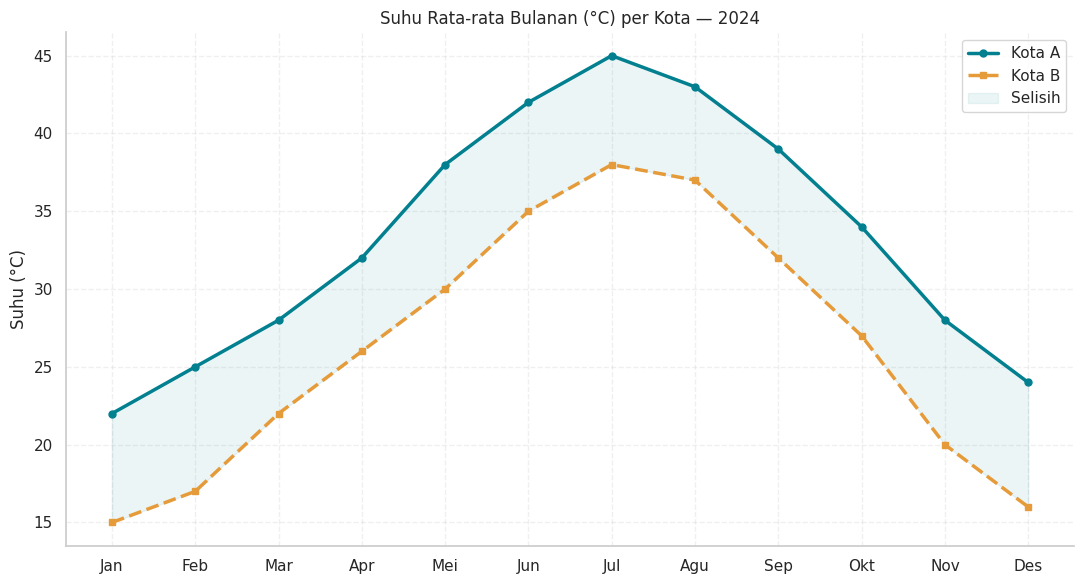

In [4]:
# Line Chart — Tren perubahan waktu
bulan  = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
kota_a = [22, 25, 28, 32, 38, 42, 45, 43, 39, 34, 28, 24]
kota_b = [15, 17, 22, 26, 30, 35, 38, 37, 32, 27, 20, 16]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(bulan, kota_a, color='#028090', linewidth=2.5, label='Kota A', marker='o', markersize=5)
ax.plot(bulan, kota_b, color='#E69B3A', linewidth=2.5, label='Kota B', linestyle='--', marker='s', markersize=5)
ax.fill_between(bulan, kota_a, kota_b, alpha=0.08, color='#028090', label='Selisih')

ax.set_title('Suhu Rata-rata Bulanan (°C) per Kota — 2024')
ax.set_ylabel('Suhu (°C)')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

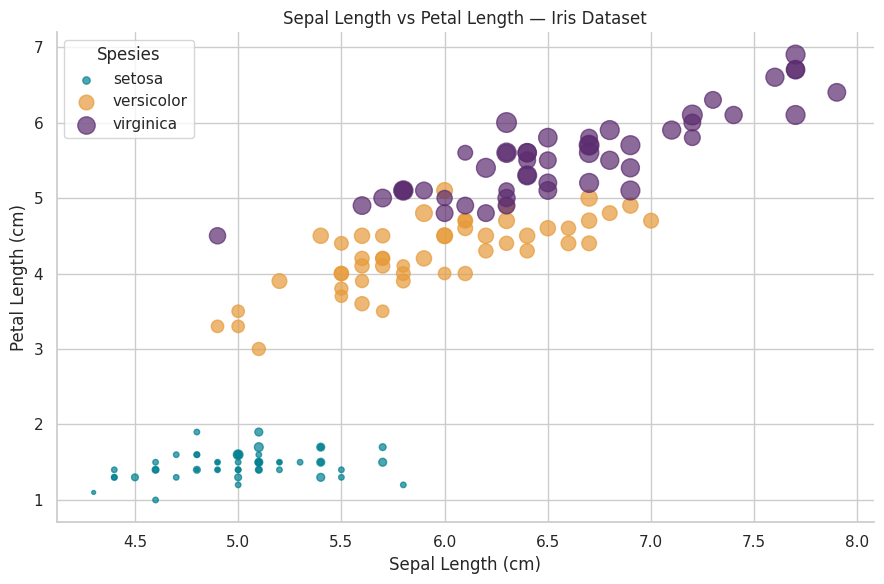

In [5]:
# Scatter Plot — Hubungan dua variabel (Iris dataset)
iris = sns.load_dataset('iris')

fig, ax = plt.subplots(figsize=(9, 6))
species_list = iris['species'].unique()
colors = ['#028090', '#E69B3A', '#5B2C6F']

for sp_name, color in zip(species_list, colors):
    subset = iris[iris['species'] == sp_name]
    ax.scatter(subset['sepal_length'], subset['petal_length'],
               c=color, label=sp_name, alpha=0.7,
               s=subset['petal_width'] * 80)

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_title('Sepal Length vs Petal Length — Iris Dataset')
ax.legend(title='Spesies')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Visualisasi Statistik dengan Seaborn

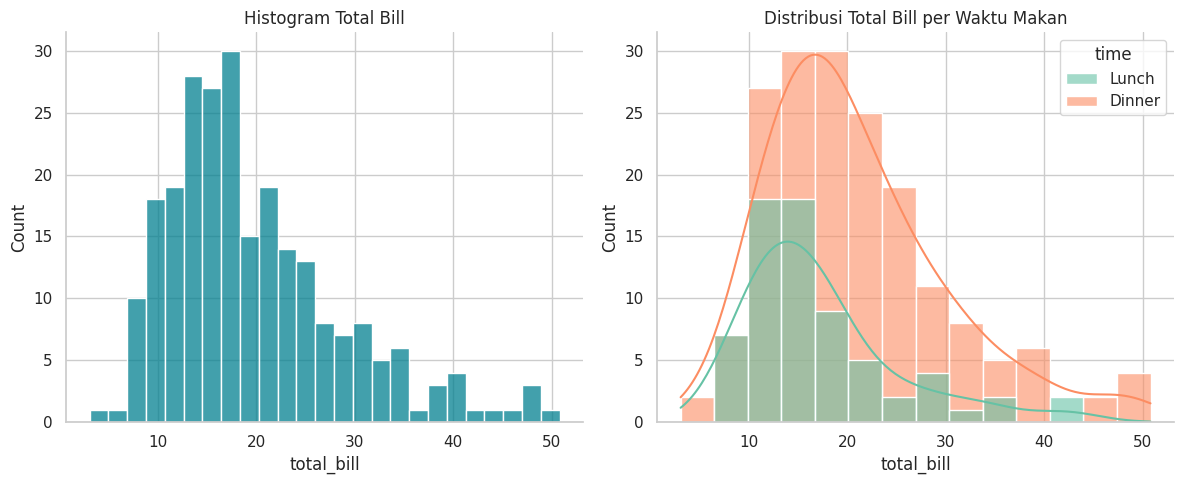

In [6]:
# Histogram & KDE — dataset tips
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['total_bill'], bins=25, color='#028090', ax=axes[0])
axes[0].set_title('Histogram Total Bill')
axes[0].spines[['top', 'right']].set_visible(False)

sns.histplot(data=df, x='total_bill', hue='time', kde=True,
             palette='Set2', alpha=0.6, ax=axes[1])
axes[1].set_title('Distribusi Total Bill per Waktu Makan')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4933/947429333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_4933/947429333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
/tmp/ipykernel_4933/947429333.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=iris, x='species', y='petal_length', palette='Set2', jitter=True, alpha=0.6, ax=axes[2])


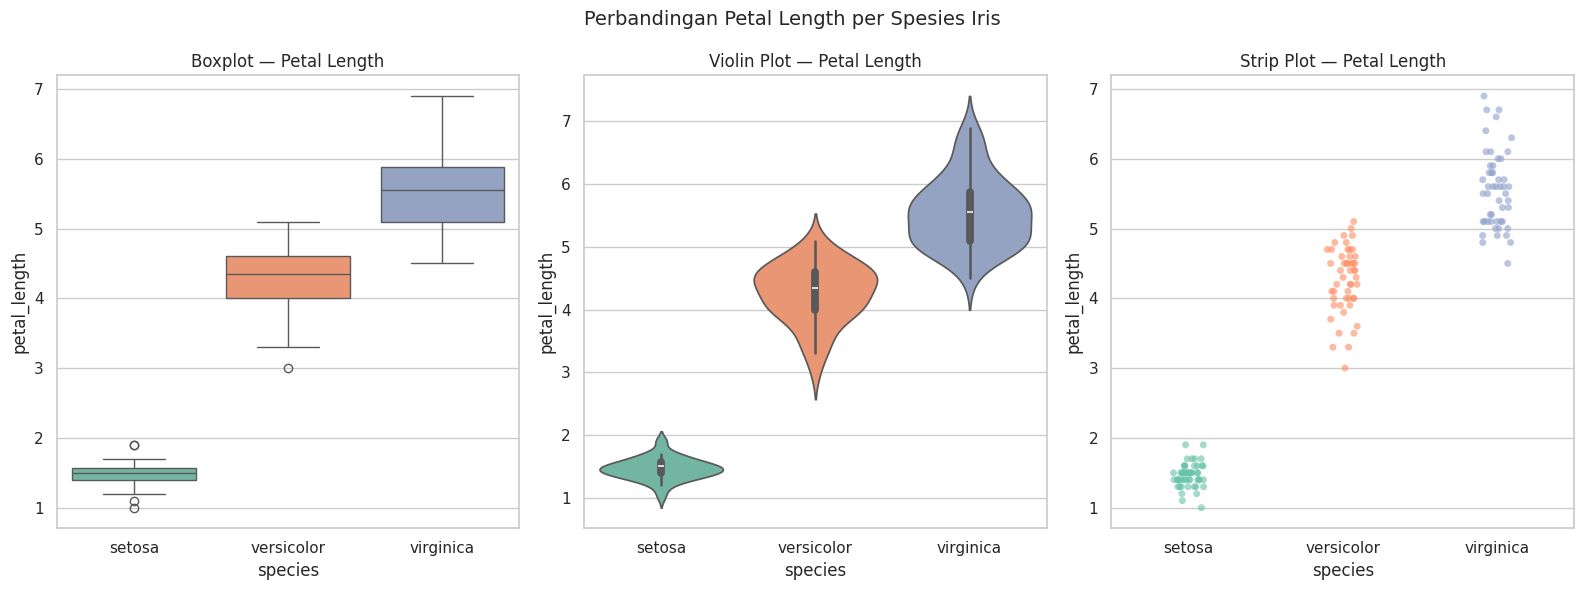

In [7]:
# Boxplot, Violin Plot, Strip Plot — Iris
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.boxplot(data=iris, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot — Petal Length')

sns.violinplot(data=iris, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot — Petal Length')

sns.stripplot(data=iris, x='species', y='petal_length', palette='Set2', jitter=True, alpha=0.6, ax=axes[2])
axes[2].set_title('Strip Plot — Petal Length')

plt.suptitle('Perbandingan Petal Length per Spesies Iris', fontsize=14)
plt.tight_layout()
plt.show()

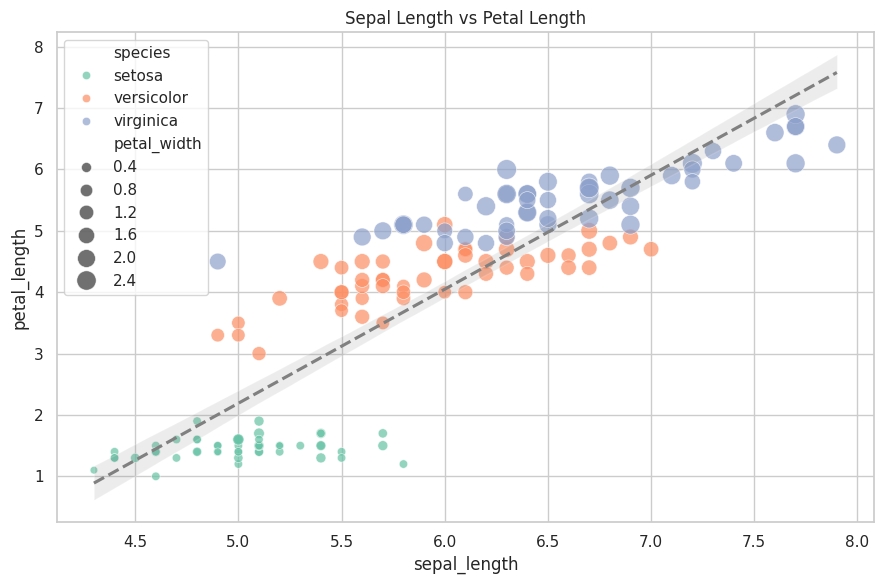

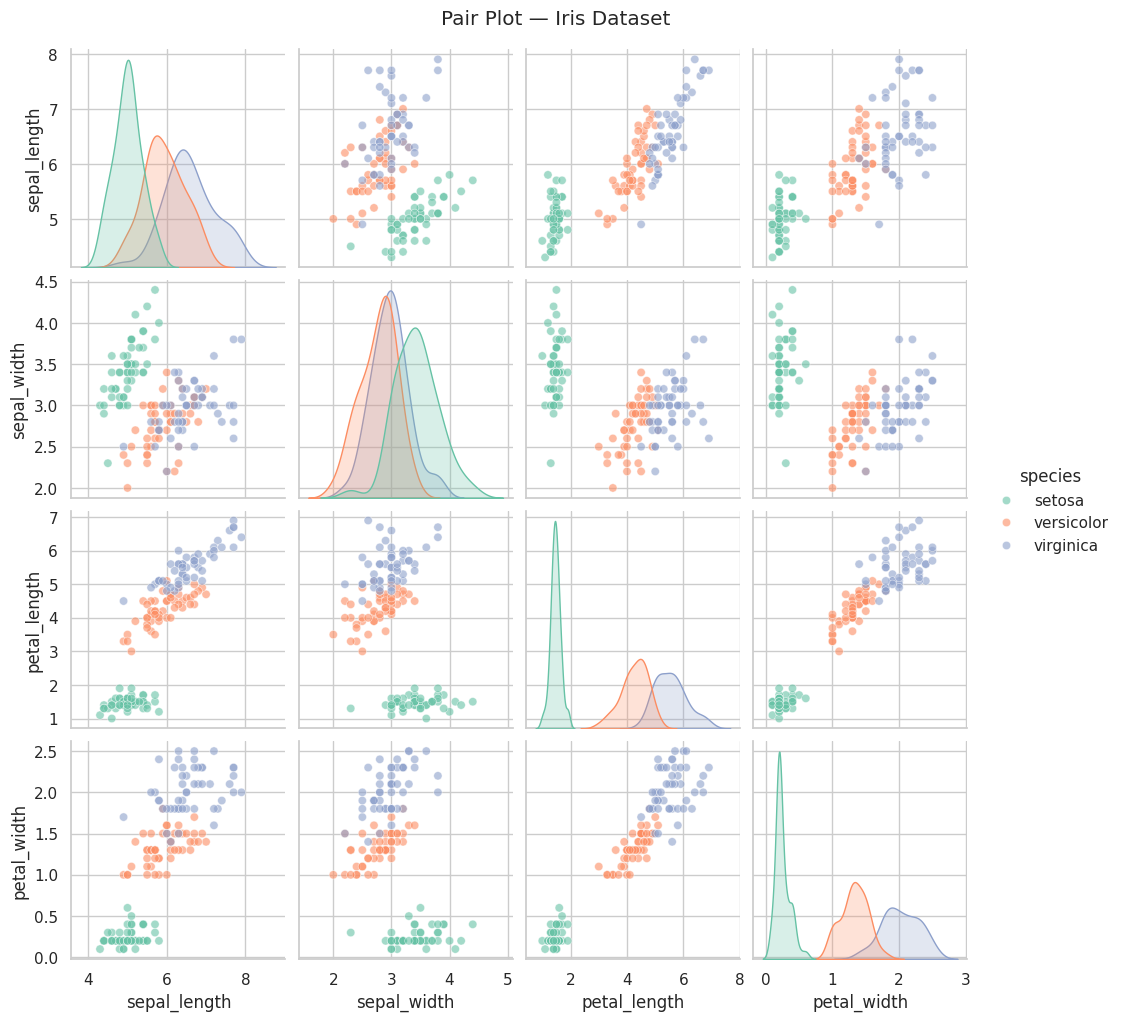

In [8]:
# Scatter Plot + Pair Plot — Iris
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',
                hue='species', size='petal_width', sizes=(30, 200),
                palette='Set2', alpha=0.7, ax=ax)
sns.regplot(data=iris, x='sepal_length', y='petal_length',
            scatter=False, color='gray', line_kws={'linestyle': '--'}, ax=ax)
ax.set_title('Sepal Length vs Petal Length')
plt.tight_layout()
plt.show()

# Pair plot
pair = sns.pairplot(iris, hue='species', palette='Set2',
                    diag_kind='kde', plot_kws={'alpha': 0.6})
pair.fig.suptitle('Pair Plot — Iris Dataset', y=1.02)
plt.show()

## 4. Dashboard Visualisasi Statis — Dataset Tips

/tmp/ipykernel_4933/1454140281.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


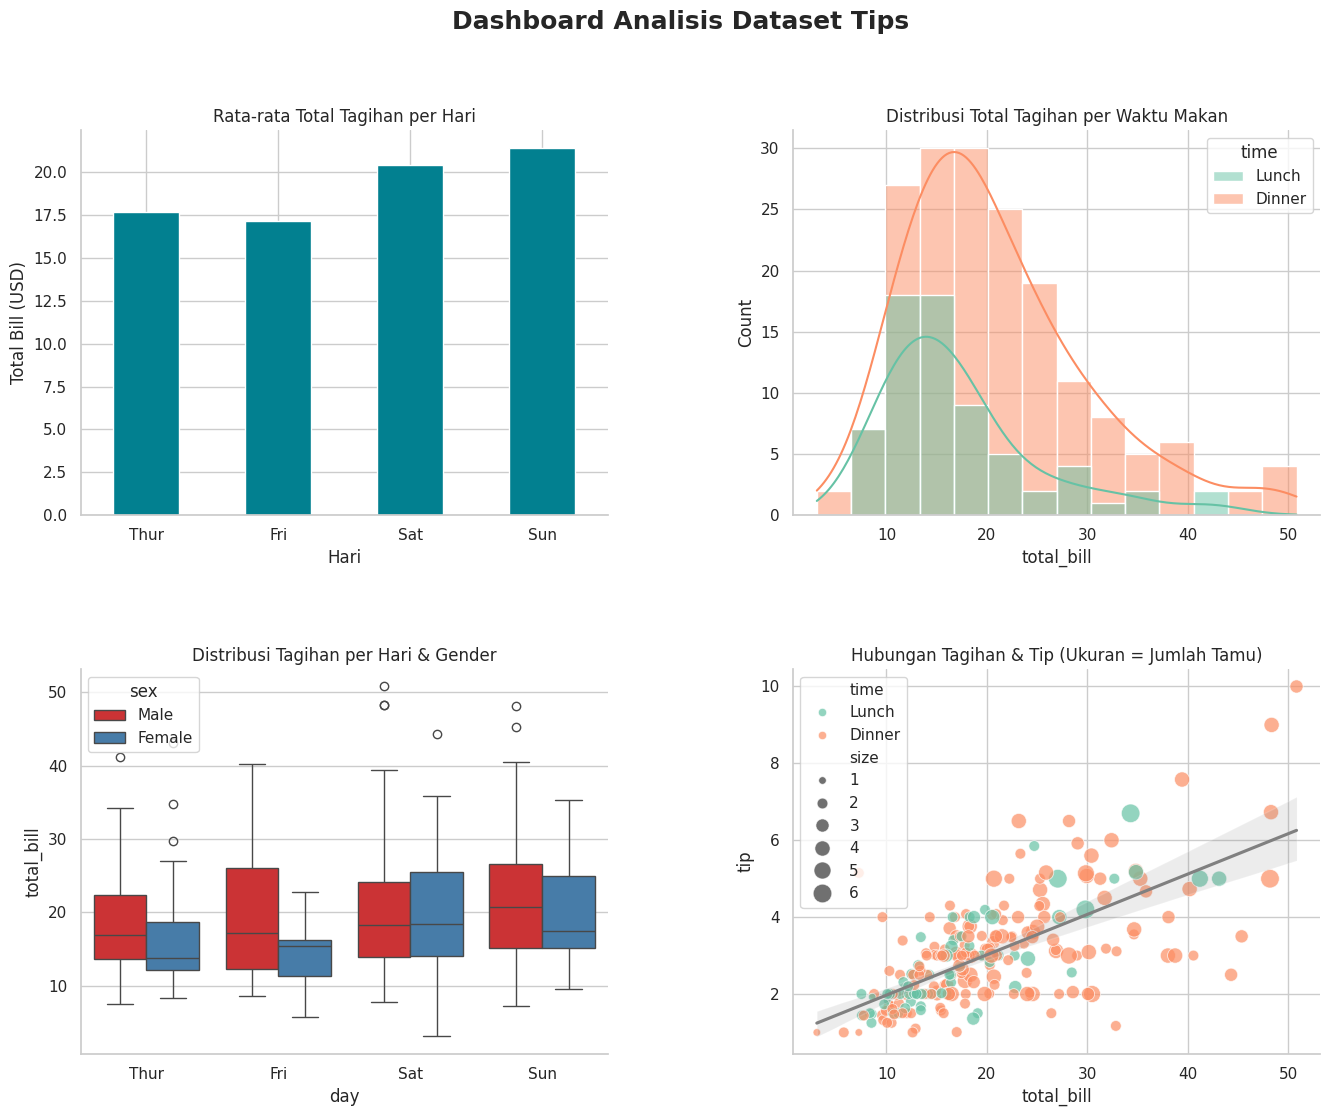

Dashboard tersimpan sebagai dashboard_tips.png


In [9]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)

gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1: Bar Chart — rata-rata tagihan per hari
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# Grafik 2: Histogram + KDE — distribusi tagihan per waktu makan
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top', 'right']].set_visible(False)

# Grafik 3: Boxplot — distribusi tagihan per hari & gender
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)

# Grafik 4: Scatter Plot — hubungan tagihan & tip
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

### Insight Grafik 1 — Rata-rata Total Tagihan per Hari

**What?** Grafik bar ini menampilkan rata-rata total tagihan (USD) per hari dalam seminggu dari dataset tips. Nilai tertinggi ada di hari Sabtu dan Minggu, sedangkan Kamis memiliki rata-rata paling rendah.

**So what?** Pelanggan di akhir pekan cenderung memesan lebih banyak, kemungkinan karena makan bersama keluarga atau acara sosial. Ini menunjukkan bahwa akhir pekan adalah waktu dengan revenue tertinggi bagi restoran.

**Now what?** Manajemen perlu memastikan staf dan persediaan lebih banyak di akhir pekan. Perlu juga dieksplorasi apakah pola ini konsisten lintas bulan atau musim tertentu.

### Insight Grafik 2 — Distribusi Total Tagihan per Waktu Makan

**What?** Histogram ini menampilkan distribusi total tagihan berdasarkan waktu makan (Lunch vs Dinner). Distribusi dinner cenderung lebih lebar dan lebih miring ke kanan dibanding lunch.

**So what?** Pelanggan dinner secara umum memiliki tagihan yang lebih besar dan lebih bervariasi, mengindikasikan bahwa sesi malam memiliki kelompok tamu yang lebih beragam, dari yang pesan sedikit hingga yang pesan banyak.

**Now what?** Strategi promosi atau paket hemat bisa difokuskan pada sesi lunch untuk meningkatkan transaksi yang nilainya cenderung lebih kecil.

### Insight Grafik 3 — Distribusi Tagihan per Hari & Gender

**What?** Boxplot ini membandingkan distribusi total tagihan per hari berdasarkan jenis kelamin. Secara umum, pelanggan laki-laki memiliki nilai tagihan yang sedikit lebih tinggi dan lebih bervariasi dibanding perempuan di hampir semua hari.

**So what?** Ada kemungkinan laki-laki lebih sering membayar tagihan untuk grup yang lebih besar, atau memilih menu yang lebih mahal. Outlier cukup banyak muncul di hari Sabtu dan Minggu.

**Now what?** Perlu dieksplorasi lebih lanjut apakah perbedaan ini berkaitan dengan ukuran grup atau pilihan menu. Data tambahan seperti jenis makanan yang dipesan bisa membantu memperjelas temuan ini.

### Insight Grafik 4 — Hubungan Tagihan & Tip

**What?** Scatter plot ini menampilkan hubungan antara total tagihan (sumbu X) dan jumlah tip (sumbu Y), dibedakan berdasarkan waktu makan dan ukuran grup (ukuran titik). Garis regresi menunjukkan tren positif yang cukup jelas.

**So what?** Semakin besar tagihan, semakin besar pula tip yang diberikan, artinya ada korelasi positif antara keduanya. Tamu dinner dengan grup besar cenderung memberikan tip yang lebih tinggi secara nominal.

**Now what?** Restoran bisa mengoptimalkan pengalaman pelanggan dinner dengan grup besar karena potensi revenue (termasuk tip) yang lebih tinggi. Perlu dicek juga apakah proporsi tip terhadap tagihan konsisten atau bervariasi.

## Kesimpulan

Pada praktikum pertemuan kelima ini saya mempelajari prinsip-prinsip visualisasi data yang efektif serta cara membuat berbagai jenis grafik menggunakan Matplotlib dan Seaborn, mulai dari bar chart, line chart, scatter plot, histogram, boxplot, violin plot, hingga pair plot dan dashboard statis.

Melalui eksplorasi dataset tips, saya memahami cara memilih grafik yang sesuai dengan tujuan analisis dan cara membaca grafik secara sistematis menggunakan pendekatan What, So what, dan Now what. Dari dashboard yang dibuat, ditemukan bahwa hari Sabtu dan Minggu memiliki rata-rata tagihan tertinggi, dan ada korelasi positif antara total tagihan dengan jumlah tip yang diberikan pelanggan.

Keterbatasan pada praktikum ini adalah dashboard yang dibuat masih bersifat statis dan belum interaktif, sehingga eksplorasi data oleh pengguna lain menjadi terbatas. Namun, praktikum ini sangat membantu dalam memahami bagaimana visualisasi yang baik bisa mengubah data mentah menjadi insight yang mudah dipahami dan dapat digunakan untuk pengambilan keputusan.